<a href="https://colab.research.google.com/github/dhouhaelaouni/image-steganography-system-/blob/main/image_stagnography.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Downloading image and libreries

In [24]:
!pip install pillow

from PIL import Image
from google.colab import files
import math
import matplotlib.pyplot as plt



XOR Encryption

 Note: XOR with a repeating key is a simple cipher used here for demonstration. In production, AES would be used

In [25]:
def xor_encrypt(message, key):
    return ''.join(chr(ord(message[i]) ^ ord(key[i % len(key)])) for i in range(len(message)))

Binary conversion

In [26]:
def text_to_binary(text):
    return ''.join(format(ord(c), '08b') for c in text)

def binary_to_text(binary):
    chars = [binary[i:i+8] for i in range(0, len(binary), 8)]
    return ''.join(chr(int(c, 2)) for c in chars)



PSNR: measures how different the stego image is from the original.

Above 40 dB = invisible to the human eye

In [27]:
def calculate_psnr(original_path, stego_path):
    original = Image.open(original_path).convert("RGB")
    stego = Image.open(stego_path).convert("RGB")

    orig_pixels = list(original.getdata())
    stego_pixels = list(stego.getdata())

    mse = sum(
        (o[c] - s[c]) ** 2
        for o, s in zip(orig_pixels, stego_pixels)
        for c in range(3)
    ) / (len(orig_pixels) * 3)

    if mse == 0:
        print("📊 PSNR: ∞ dB (images are perfectly identical)")
        return

    psnr = 10 * math.log10(255**2 / mse)
    print(f"📊 PSNR: {psnr:.2f} dB  (above 40 dB = imperceptible to the human eye)")
    if psnr >= 40:
        print("   ✅ Result: Changes are imperceptible to the human eye.")
    else:
        print("   ⚠️  Result: Changes may be visible — consider using a larger image.")




STEGANALYSIS: compares the pixel color distribution(histogram) of the original vs stego image

If the distributions are very similar, the hidden data is not causing obvious statistical anomalies.

In [28]:
def histogram_similarity(original_path, stego_path):
    original = Image.open(original_path).convert("RGB")
    stego    = Image.open(stego_path).convert("RGB")

    orig_pixels  = list(original.getdata())
    stego_pixels = list(stego.getdata())

    # Build a frequency count for each of the 256 possible
    # values across all three color channels (R, G, B)
    orig_hist  = [0] * 256
    stego_hist = [0] * 256

    for op, sp in zip(orig_pixels, stego_pixels):
        for c in range(3):
            orig_hist[op[c]]  += 1
            stego_hist[sp[c]] += 1

    # Measure how different the two histograms are using
    # the sum of absolute differences, then convert to a
    # similarity percentage (100% = identical distributions)
    total_values   = len(orig_pixels) * 3
    total_diff     = sum(abs(orig_hist[i] - stego_hist[i]) for i in range(256))
    similarity_pct = (1 - total_diff / (2 * total_values)) * 100
    print(f"   📈 Histogram Similarity : {similarity_pct:.2f}%")
    if similarity_pct >= 99.0:
        print("   ✅ Result: No statistically detectable anomaly.")
    elif similarity_pct >= 95.0:
        print("   ⚠️  Result: Minor difference — acceptable for LSB embedding.")
    else:
        print("   ❌ Result: Notable difference — try a larger image.")


Visual Comparison

In [29]:
def show_comparison(original_path, stego_path):
    original = Image.open(original_path).convert("RGB")
    stego    = Image.open(stego_path).convert("RGB")

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    axes[0].imshow(original)
    axes[0].set_title("Original Image", fontsize=13)
    axes[0].axis("off")

    axes[1].imshow(stego)
    axes[1].set_title("Stego Image (message hidden inside)", fontsize=13)
    axes[1].axis("off")

    plt.suptitle("Visual Comparison — Can you spot the difference?", fontsize=14)
    plt.tight_layout()
    plt.show()


Encode : hidding the message inside the image

In [30]:
def encode_image(image_path, message, key, output_path):
    image = Image.open(image_path).convert("RGB")
    pixels = list(image.getdata())

    # Encrypt the message then add the stop marker
    encrypted = xor_encrypt(message + "###END###", key)
    binary_message = text_to_binary(encrypted)

    # Check the message fits inside the image
    max_bits = len(pixels) * 3
    required_bits = len(binary_message)
    print(f"📦 Image capacity : {max_bits // 8} characters")
    print(f"📨 Message needs  : {required_bits // 8} characters")

    if required_bits > max_bits:
        raise ValueError("❌ Message is too long for this image. Use a larger image or a shorter message.")

    # Embed each bit of the message into the LSB of each color channel
    new_pixels = []
    msg_index = 0

    for pixel in pixels:
        r, g, b = pixel

        if msg_index < len(binary_message):
            r = (r & ~1) | int(binary_message[msg_index])
            msg_index += 1

        if msg_index < len(binary_message):
            g = (g & ~1) | int(binary_message[msg_index])
            msg_index += 1

        if msg_index < len(binary_message):
            b = (b & ~1) | int(binary_message[msg_index])
            msg_index += 1

        new_pixels.append((r, g, b))

    image.putdata(new_pixels)

    # Save as PNG — JPEG compression would destroy the hidden bits
    print("💾 Saving as PNG (lossless) — JPEG compression would destroy the hidden bits.")
    image.save(output_path)
    print("✅ Message encoded successfully!")

Decode : Extract the hidden message from the image

In [31]:
def decode_image(image_path, key):
    image = Image.open(image_path).convert("RGB")
    pixels = list(image.getdata())

    # Read the LSB of every color channel back into a binary string
    binary_data = ""
    for pixel in pixels:
        r, g, b = pixel
        binary_data += str(r & 1)
        binary_data += str(g & 1)
        binary_data += str(b & 1)

    # Convert binary back to characters, stop when we hit ###END###
    all_bytes = [binary_data[i:i+8] for i in range(0, len(binary_data), 8)]

    raw_message = ""
    for byte in all_bytes:
        char = chr(int(byte, 2))
        raw_message += char
        if "###END###" in raw_message:
            break

    # FIX: cut everything at the stop marker before decrypting
    if "###END###" not in raw_message:
        print("❌ No hidden message found, or wrong password.")
        return

    clean_message = raw_message[:raw_message.index("###END###")]
    decrypted = xor_encrypt(clean_message, key)
    print("🔓 Hidden message:", decrypted)


Main flow

  IT360 — Image Steganography System
  Tunis Business School | 2025-2026

📤 Step 1: Upload your cover image


Saving asus.jpg to asus (1).jpg
   Image loaded: asus (1).jpg

Enter your secret message : whatever lets talk about anything this test are sometimes very demanding i cant think of any serious test message lets test END will it get stuck there or will it continue the work ok maybe tahts enaught or . i should add some ; : 7522 how will they be encrypted 
Enter password            : IT360

🔒 Step 2: Encoding message into image...
📦 Image capacity : 777600 characters
📨 Message needs  : 272 characters
💾 Saving as PNG (lossless) — JPEG compression would destroy the hidden bits.
✅ Message encoded successfully!

📥 Step 3: Downloading stego image...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


🖼️  Step 4: Visual comparison — original vs stego image


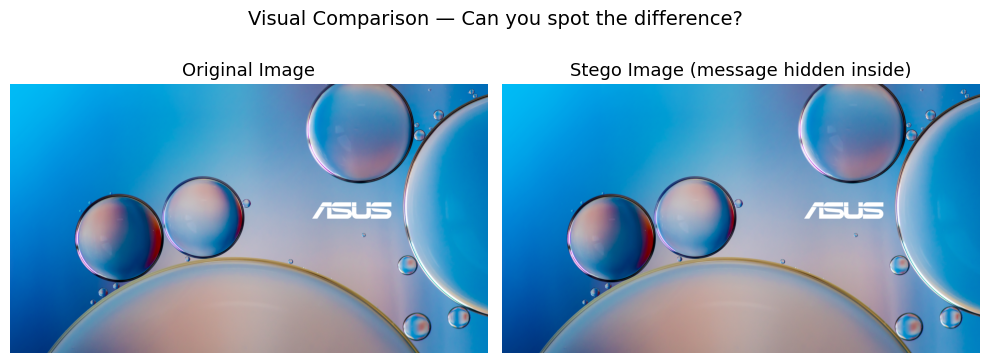


📐 Step 5: Image quality measurement (PSNR)
📊 PSNR: 85.76 dB  (above 40 dB = imperceptible to the human eye)
   ✅ Result: Changes are imperceptible to the human eye.

🔬 Step 6: Steganalysis — histogram similarity test
   📈 Histogram Similarity : 99.99%
   ✅ Result: No statistically detectable anomaly.

🔍 Step 7: Decoding to verify message integrity...
❌ No hidden message found, or wrong password.

  All steps completed successfully.


In [33]:

print("=" * 55)
print("  IT360 — Image Steganography System")
print("  Tunis Business School | 2025-2026")
print("=" * 55)

# --- Upload ---
print("\n📤 Step 1: Upload your cover image")
uploaded   = files.upload()
image_name = list(uploaded.keys())[0]
print(f"   Image loaded: {image_name}")

# --- Inputs ---
message = input("\nEnter your secret message : ")
key     = input("Enter password            : ")

output_image = "output.png"

# --- Step 2: Encode ---
print("\n🔒 Step 2: Encoding message into image...")
encode_image(image_name, message, key, output_image)

# --- Step 3: Download ---
print("\n📥 Step 3: Downloading stego image...")
files.download(output_image)

# --- Step 4: Visual Comparison ---
print("\n🖼️  Step 4: Visual comparison — original vs stego image")
show_comparison(image_name, output_image)

# --- Step 5: PSNR ---
print("\n📐 Step 5: Image quality measurement (PSNR)")
calculate_psnr(image_name, output_image)

# --- Step 6: Steganalysis ---
print("\n🔬 Step 6: Steganalysis — histogram similarity test")
histogram_similarity(image_name, output_image)

# --- Step 7: Decode ---
print("\n🔍 Step 7: Decoding to verify message integrity...")
decode_image(output_image, key)

print("\n" + "=" * 55)
print("  All steps completed successfully.")
print("=" * 55)